# Fase 5 (anexo) — CNN con split consciente de grupos

Reentrena la CNN desde cero usando el split SIN fuga (grupos de casi-duplicados íntegros por partición) y la evalúa en su test. Permite estimar el desempeño honesto de la CNN, comparable con el del split aleatorio.

> Requiere `artifacts/group_split.csv` (generado por `05_evaluacion.ipynb`).

## 0. Configuración y carga del split por grupos

In [1]:
import sys, time, json
from pathlib import Path
root = Path.cwd()
while not (root / 'src').exists() and root != root.parent:
    root = root.parent
sys.path.insert(0, str(root))

import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import classification_report

from src.data.dataset import build_index, QUALITY_ORDER
from src.data import preprocess as pp
from src.models.cnn import build_cnn
from src.evaluation.metrics import plot_confusion, summary_row

sns.set_theme(style='whitegrid')
np.random.seed(42); tf.random.set_seed(42)
ART = root / 'artifacts'

df = pp.clean_index(build_index())
gs = pd.read_csv(ART/'group_split.csv')
df = df.merge(gs[['path','gsplit']], on='path', how='inner')
print('Split por grupos:', df['gsplit'].value_counts().to_dict())

Split por grupos: {'train': 5436, 'val': 1221, 'test': 1146}


## 1. Cargar imágenes (train/val/test del split por grupos)

In [2]:
label2idx = {q:i for i,q in enumerate(QUALITY_ORDER)}
t0=time.time()
Xtr,ytr = pp.load_images_uint8(df[df.gsplit=='train'], verbose=False)
Xva,yva = pp.load_images_uint8(df[df.gsplit=='val'], verbose=False)
Xte,yte = pp.load_images_uint8(df[df.gsplit=='test'], verbose=False)
ytr_i=np.array([label2idx[q] for q in ytr]); yva_i=np.array([label2idx[q] for q in yva])
print(f'Imágenes cargadas en {time.time()-t0:.0f}s | train {Xtr.shape[0]} val {Xva.shape[0]} test {Xte.shape[0]}')

Imágenes cargadas en 227s | train 5436 val 1221 test 1146


## 2. Datasets, pesos de clase, modelo

In [3]:
BATCH=32; AUTOTUNE=tf.data.AUTOTUNE
train_ds=(tf.data.Dataset.from_tensor_slices((Xtr,ytr_i)).shuffle(2048,seed=42).batch(BATCH).prefetch(AUTOTUNE))
val_ds=tf.data.Dataset.from_tensor_slices((Xva,yva_i)).batch(BATCH).prefetch(AUTOTUNE)
cw=pp.class_weights(df[df.gsplit=='train']['quality'])
class_weight={label2idx[k]:v for k,v in cw.items()}
model=build_cnn(input_shape=(128,128,3), n_classes=len(QUALITY_ORDER), augment=True)
model.compile(optimizer=keras.optimizers.Adam(1e-3), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
print('class_weight:', {k:round(v,3) for k,v in class_weight.items()})

class_weight: {0: 1.502, 1: 0.774, 2: 0.96}


## 3. Entrenamiento

In [4]:
callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss',patience=6,restore_best_weights=True),
           keras.callbacks.ReduceLROnPlateau(monitor='val_loss',factor=0.5,patience=3,min_lr=1e-5)]
t0=time.time()
history=model.fit(train_ds, validation_data=val_ds, epochs=30, class_weight=class_weight, callbacks=callbacks, verbose=2)
print(f'Entrenamiento en {time.time()-t0:.0f}s ({len(history.history["loss"])} épocas)')
model.save(ART/'cnn_groups.keras')

Epoch 1/30


170/170 - 26s - 151ms/step - accuracy: 0.8122 - loss: 0.5331 - val_accuracy: 0.4259 - val_loss: 1.5786 - learning_rate: 0.0010


Epoch 2/30


170/170 - 25s - 147ms/step - accuracy: 0.8274 - loss: 0.4804 - val_accuracy: 0.6822 - val_loss: 0.7780 - learning_rate: 0.0010


Epoch 3/30


...

Epoch 23/30


170/170 - 25s - 146ms/step - accuracy: 0.9104 - loss: 0.2456 - val_accuracy: 0.8960 - val_loss: 0.3065 - learning_rate: 2.5000e-04


Epoch 24/30


170/170 - 25s - 146ms/step - accuracy: 0.9178 - loss: 0.2373 - val_accuracy: 0.9148 - val_loss: 0.2195 - learning_rate: 2.5000e-04


Entrenamiento en 601s (24 épocas)


## 4. Curvas de entrenamiento

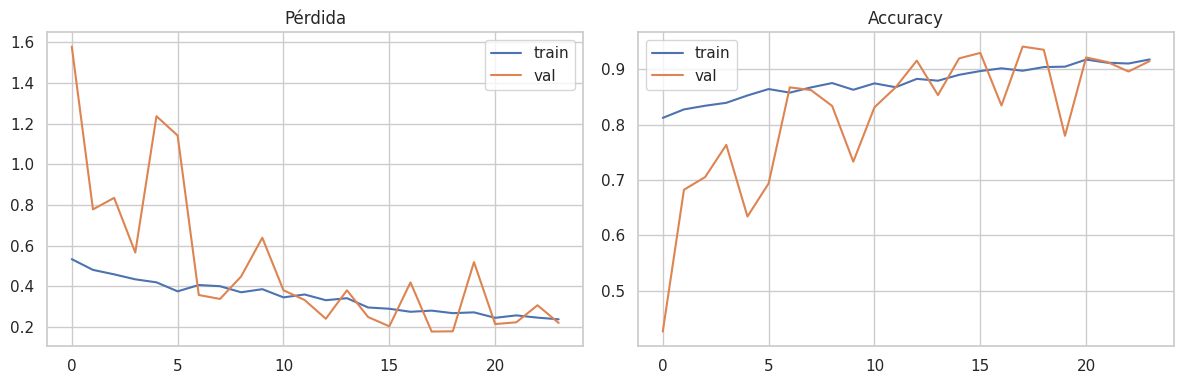

In [5]:
h=history.history
fig,axes=plt.subplots(1,2,figsize=(12,4))
axes[0].plot(h['loss'],label='train'); axes[0].plot(h['val_loss'],label='val'); axes[0].set_title('Pérdida'); axes[0].legend()
axes[1].plot(h['accuracy'],label='train'); axes[1].plot(h['val_accuracy'],label='val'); axes[1].set_title('Accuracy'); axes[1].legend()
plt.tight_layout(); plt.show()

## 5. Evaluación en el TEST por grupos

{'modelo': 'CNN — split por grupos', 'macro_f1': 0.9464, 'balanced_acc': 0.9433, 'recall_Bad': 0.8759}


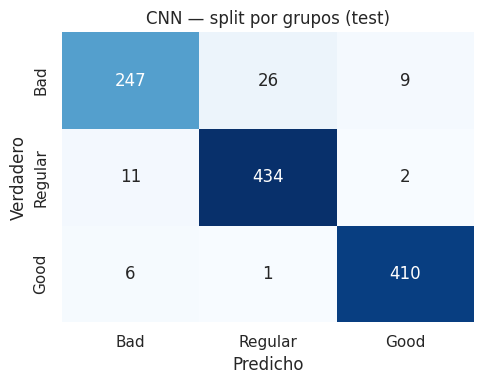

              precision    recall  f1-score   support

         Bad       0.94      0.88      0.90       282
     Regular       0.94      0.97      0.96       447
        Good       0.97      0.98      0.98       417

    accuracy                           0.95      1146
   macro avg       0.95      0.94      0.95      1146
weighted avg       0.95      0.95      0.95      1146

Métricas guardadas en cnn_groups_metrics.json


In [6]:
proba=model.predict(Xte, batch_size=32, verbose=0)
pred=np.array([QUALITY_ORDER[i] for i in proba.argmax(1)])
row=summary_row('CNN — split por grupos', yte, pred)
print(row)
fig,ax=plt.subplots(figsize=(5,4)); plot_confusion(yte,pred,ax,'CNN — split por grupos (test)'); plt.tight_layout(); plt.show()
print(classification_report(yte,pred,labels=QUALITY_ORDER,zero_division=0))
json.dump(row, open(ART/'cnn_groups_metrics.json','w'))
print('Métricas guardadas en cnn_groups_metrics.json')